In [1]:
import torch
import torch.optim as optim

from src.dataloader import get_loaders
from src.eval import test_evaluation
from src.train import ComboLoss, run_training, plot_train_history
from src.model_unet import UNet

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using MPS (Apple Silicon GPU)


In [3]:
# Config Hyperparameters (Adjust)
NUM_CLASSES = 5
BATCH_SIZE = 4
LR = 1e-4
NUM_EPOCHS = 1
PATIENCE = 5
BASE_FEATURES = 32
SAVE_PATH = "best_unet.pth"

In [4]:
# Create Data Splits
from Preprocessing.xBD_splits import create_splits
img_dir = r"../Preprocessing/tiles/images"
mask_dir = r"../Preprocessing/tiles/masks"
train_files, val_files, test_files = create_splits(img_dir, mask_dir)
print(f"Train: {len(train_files)}  Val: {len(val_files)}  Test: {len(test_files)}")

Train: 12016
Val: 84
Test: 1592
Train: 12016  Val: 84  Test: 1592


In [5]:
train_loader, val_loader, test_loader = get_loaders(
    train_files, val_files, test_files, img_dir, mask_dir,
    batch_size=BATCH_SIZE, augment_train=False)

In [6]:
# Sanity check
images, masks = next(iter(train_loader))
print(f"Batch images: {images.shape}")  # [B, 6, H, W]
print(f"Batch masks:  {masks.shape}")   # [B, H, W]
print(f"Mask range:   {masks.min()} – {masks.max()}")

Batch images: torch.Size([4, 6, 512, 512])
Batch masks:  torch.Size([4, 512, 512])
Mask range:   0 – 3


In [7]:
# Loss — ComboLoss (CE + Tversky)
class_counts = torch.tensor([
    3258249517, 287893139, 15076019, 19138232, 8918741
], dtype=torch.float32)

freqs = class_counts / class_counts.sum()
weights = 1.0 / torch.sqrt(freqs)
weights = weights / weights.mean()
class_weights = weights.to(device)

In [8]:
# Model
model = UNet(
    in_channels=6,
    num_classes=NUM_CLASSES,
    base_features=BASE_FEATURES).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 7,764,037


In [9]:
# Loss, Optimizer, LR Scheduler (Define Here)
criterion = ComboLoss(class_weights=class_weights, ce_weight=0.5,
                      tversky_weight=0.5, tversky_alpha=0.7,
                      tversky_beta=0.3, num_classes=NUM_CLASSES).to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

In [10]:
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    num_classes=NUM_CLASSES,
    save_path=SAVE_PATH, verbose = True)



Epoch 1/1  (lr=1.00e-04)
  Train Loss: 0.6856  |  Val Loss: 0.4541
  Train mIoU: 0.2935  |  Val mIoU: 0.2920
  Train Acc:  0.9011  |  Val Acc:  0.9764
  Val Per-Class:
    Class                IoU     Prec   Recall
    -----------------------------------------
    No Damage         0.9787   0.9884   0.9901
    Minor             0.4489   0.6790   0.5697
    Major             0.0000   0.0000   0.0000
    Destroyed         0.0069   0.0073   0.1024
    Unclassified      0.0253   0.0295   0.1536
  *** Saved new best model (mIoU=0.2920) ***


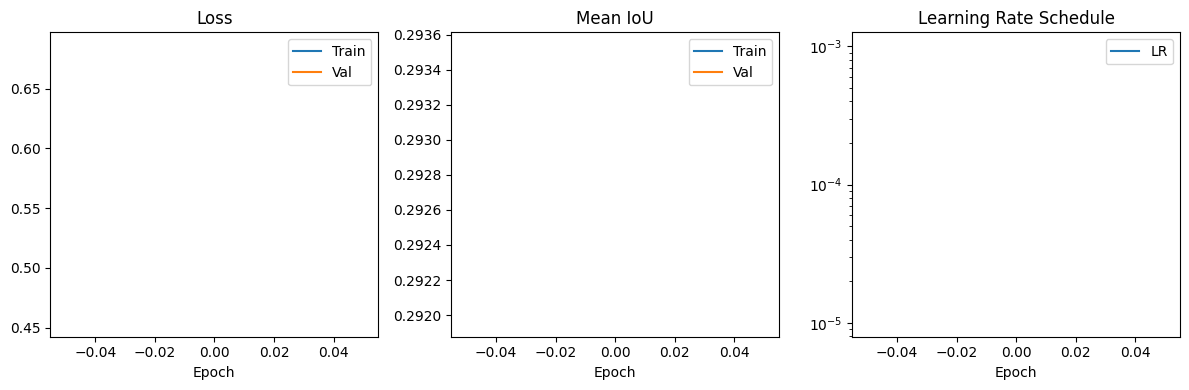

In [11]:
plot_train_history(history)

In [12]:
test_loss, test_metrics = test_evaluation(model, test_loader, criterion, device, SAVE_PATH, NUM_CLASSES)

Test Loss: 0.4536
Test mIoU: 0.3293
Test Acc:  0.9801

Class                IoU     Prec   Recall
No Damage         0.9845   0.9911   0.9933
Minor             0.4741   0.6930   0.6003
Major             0.0023   0.0274   0.0026
Destroyed         0.1561   0.2247   0.3383
Unclassified      0.0291   0.0322   0.2351
